# Customer Churn Prediction — Exploratory Data Analysis

**Stage 2** of the Customer Churn Prediction with Explainable AI project.

This notebook explores the cleaned dataset produced by Stage 1 (`run_stage1.py`)
to understand which customer characteristics are associated with churn, before
any model is trained.

**A note on which split is used:** all analysis below uses the **training split
only** (`data/processed/train.csv`, 5,634 rows). The test set is deliberately
left untouched so that no decision made while looking at these charts can be
influenced by data reserved for final evaluation. Because the Stage 1 split is
stratified, the churn rate is identical in both halves (26.54%), so this costs
nothing in terms of representativeness.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve the project root so the notebook runs from anywhere, then reuse the
# Stage 1 configuration rather than re-declaring paths.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config

FIGURES = config.FIGURES_DIR
FIGURES.mkdir(parents=True, exist_ok=True)

# Consistent styling across every figure.
sns.set_theme(style="whitegrid", context="notebook")
NO, YES = "#4C78A8", "#E45756"
CHURN_PALETTE = {0: NO, 1: YES}
plt.rcParams["figure.dpi"] = 110


def save(fig, name):
    """Save a figure to reports/figures/ and report the path."""
    path = FIGURES / name
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"saved -> reports/figures/{name}")
    return path


df = pd.read_csv(config.TRAIN_CSV)
print(f"rows: {len(df):,}   columns: {df.shape[1]}")
print(f"churn rate: {df['Churn'].mean():.4f}")
df.head()

rows: 5,634   columns: 23
churn rate: 0.2654


,tenure,MonthlyCharges,TotalCharges,avg_charge,num_services,is_new_customer,SeniorCitizen,gender,Partner,Dependents,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,35,49.20,1701.65,48.618571,4,0,0,Male,No,No,...,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,0
1,15,75.10,1151.55,76.770000,3,0,0,Male,Yes,Yes,...,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,0
2,13,40.55,590.35,45.411538,4,0,0,Male,Yes,Yes,...,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,0
3,26,73.50,1905.70,73.296154,6,0,0,Female,Yes,No,...,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),0
4,1,44.55,44.55,44.550000,2,0,0,Male,Yes,Yes,...,No,No,No,No,No,No,Month-to-month,No,Electronic check,0


In [2]:
# A reusable helper: churn count and churn rate for any categorical column.
def churn_by(col, data=df):
    out = (data.groupby(col, observed=True)["Churn"]
               .agg(customers="size", churned="sum", churn_rate="mean"))
    out["churn_rate_pct"] = (out["churn_rate"] * 100).round(2)
    out["retained"] = out["customers"] - out["churned"]
    return out.sort_values("churn_rate", ascending=False)


def plot_categorical(col, filename, title, order=None):
    """Two panels: stacked customer counts, and churn rate with a mean line."""
    stats = churn_by(col)
    if order is not None:
        stats = stats.loc[order]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].bar(stats.index.astype(str), stats["retained"], label="Retained", color=NO)
    axes[0].bar(stats.index.astype(str), stats["churned"],
                bottom=stats["retained"], label="Churned", color=YES)
    axes[0].set_title(f"Customer count by {col}")
    axes[0].set_ylabel("Customers")
    axes[0].legend()

    bars = axes[1].bar(stats.index.astype(str), stats["churn_rate_pct"], color=YES)
    axes[1].axhline(df["Churn"].mean() * 100, ls="--", c="gray",
                    label=f"Overall {df['Churn'].mean() * 100:.2f}%")
    axes[1].bar_label(bars, fmt="%.2f%%", padding=2, fontsize=9)
    axes[1].set_title(f"Churn rate by {col}")
    axes[1].set_ylabel("Churn rate (%)")
    axes[1].set_ylim(0, max(stats["churn_rate_pct"]) * 1.18)
    axes[1].legend()

    for ax in axes:
        ax.tick_params(axis="x", rotation=15)
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    save(fig, filename)
    plt.show()
    return stats

## 1. Churn distribution

How many customers churned, in absolute and percentage terms. This sets the
class balance that every later modelling decision has to respect.

saved -> reports/figures/churn_distribution.png


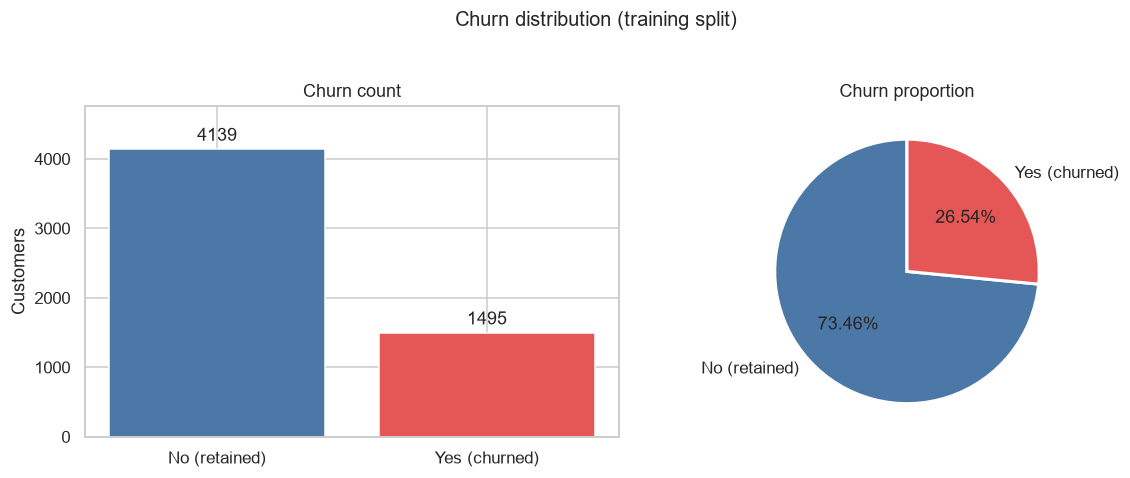

Retained : 4,139  (73.46%)
Churned  : 1,495  (26.54%)

Majority-class baseline accuracy: 0.7346
A model predicting 'No churn' for everyone would score this accuracy
while catching zero churners -- so accuracy alone is not a sufficient metric.


In [3]:
counts = df["Churn"].value_counts().sort_index()
pcts = df["Churn"].value_counts(normalize=True).sort_index() * 100
labels = ["No (retained)", "Yes (churned)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

bars = axes[0].bar(labels, counts.values, color=[NO, YES])
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_title("Churn count")
axes[0].set_ylabel("Customers")
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values, labels=labels, colors=[NO, YES],
            autopct="%1.2f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn proportion")

fig.suptitle("Churn distribution (training split)", fontsize=13, y=1.03)
fig.tight_layout()
save(fig, "churn_distribution.png")
plt.show()

print(f"Retained : {counts[0]:>5,}  ({pcts[0]:.2f}%)")
print(f"Churned  : {counts[1]:>5,}  ({pcts[1]:.2f}%)")
print(f"\nMajority-class baseline accuracy: {pcts[0] / 100:.4f}")
print("A model predicting 'No churn' for everyone would score this accuracy")
print("while catching zero churners -- so accuracy alone is not a sufficient metric.")

## 2. Tenure vs churn

Tenure is how many months the customer has been with the company. Two views:
the distribution of tenure for each group, and the churn rate within tenure
bands.

saved -> reports/figures/tenure_vs_churn.png


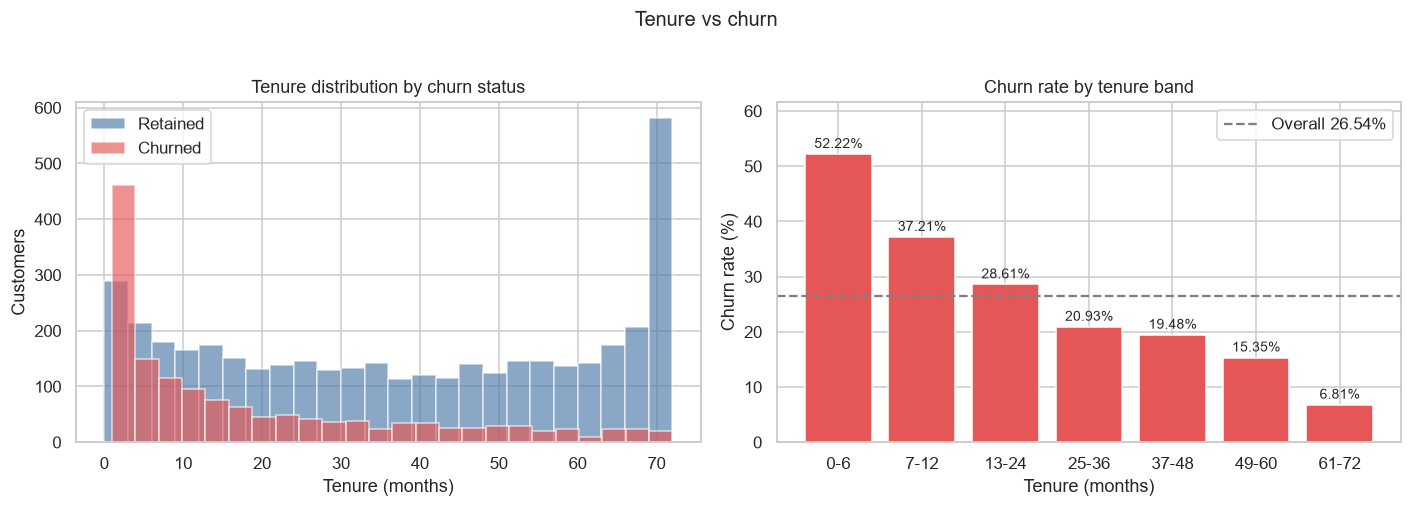

             customers  churned  churn_rate_pct
tenure_band                                    
0-6               1170      611           52.22
7-12               567      211           37.21
13-24              818      234           28.61
25-36              669      140           20.93
37-48              621      121           19.48
49-60              658      101           15.35
61-72             1131       77            6.81

Mean tenure -- retained: 37.59 months, churned: 18.36 months
Median tenure -- retained: 38.0, churned: 10.0
Correlation of tenure with churn: -0.3456


In [4]:
bins = [0, 6, 12, 24, 36, 48, 60, 72]
band_labels = ["0-6", "7-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df["tenure_band"] = pd.cut(df["tenure"], bins=bins, labels=band_labels,
                           include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for churn_value, name in [(0, "Retained"), (1, "Churned")]:
    axes[0].hist(df.loc[df["Churn"] == churn_value, "tenure"], bins=24,
                 alpha=0.65, label=name, color=CHURN_PALETTE[churn_value])
axes[0].set_title("Tenure distribution by churn status")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Customers")
axes[0].legend()

band_stats = (df.groupby("tenure_band", observed=True)["Churn"]
                .agg(customers="size", churned="sum", churn_rate="mean"))
band_stats["churn_rate_pct"] = (band_stats["churn_rate"] * 100).round(2)

bars = axes[1].bar(band_stats.index.astype(str), band_stats["churn_rate_pct"],
                   color=YES)
axes[1].bar_label(bars, fmt="%.2f%%", padding=2, fontsize=9)
axes[1].axhline(df["Churn"].mean() * 100, ls="--", c="gray",
                label=f"Overall {df['Churn'].mean() * 100:.2f}%")
axes[1].set_title("Churn rate by tenure band")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_ylim(0, band_stats["churn_rate_pct"].max() * 1.18)
axes[1].legend()

fig.suptitle("Tenure vs churn", fontsize=13, y=1.02)
fig.tight_layout()
save(fig, "tenure_vs_churn.png")
plt.show()

print(band_stats[["customers", "churned", "churn_rate_pct"]].to_string())
print(f"\nMean tenure -- retained: {df.loc[df.Churn == 0, 'tenure'].mean():.2f} months, "
      f"churned: {df.loc[df.Churn == 1, 'tenure'].mean():.2f} months")
print(f"Median tenure -- retained: {df.loc[df.Churn == 0, 'tenure'].median():.1f}, "
      f"churned: {df.loc[df.Churn == 1, 'tenure'].median():.1f}")
print(f"Correlation of tenure with churn: {df['tenure'].corr(df['Churn']):.4f}")

## 3. Monthly charges vs churn

Whether customers who churn are paying more. The quartile panel checks whether
any relationship is actually monotonic, rather than assuming it is.

saved -> reports/figures/monthly_charges_vs_churn.png


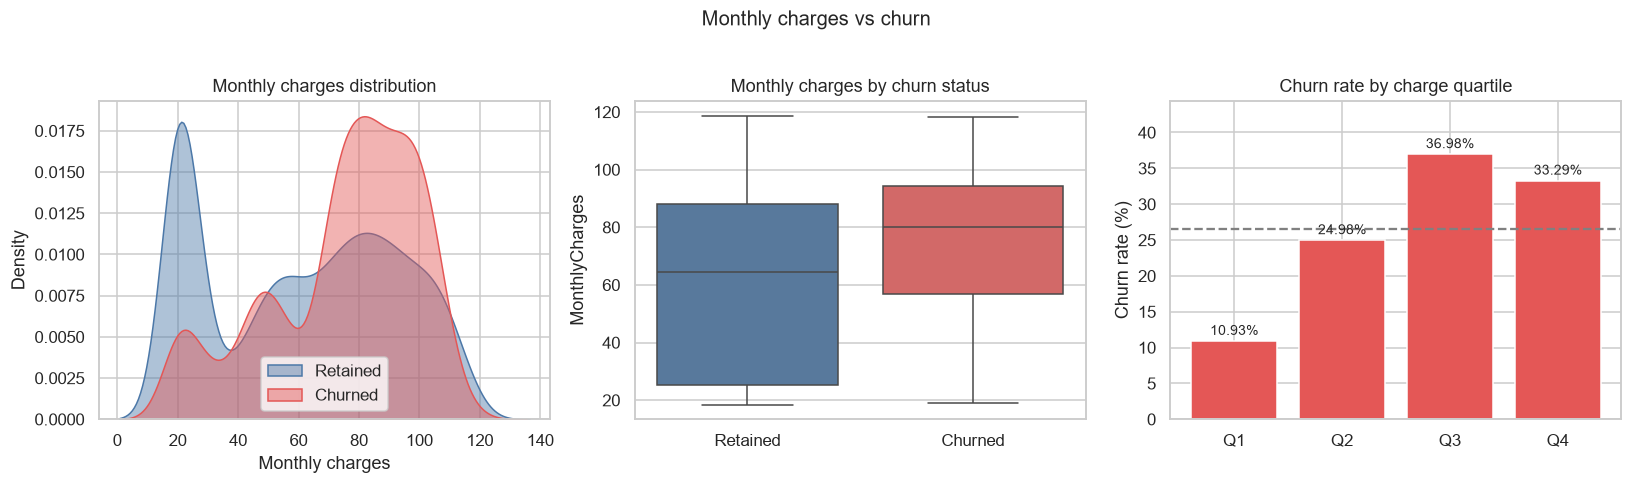

Mean monthly charges -- retained: 61.34, churned: 74.86
Median monthly charges -- retained: 64.40, churned: 79.95

Churn rate by monthly-charge quartile:
  Q1  (18.398999999999997, 35.662] n=1409  10.93%
  Q2  (35.662, 70.5]             n=1413  24.98%
  Q3  (70.5, 90.0]               n=1406  36.98%
  Q4  (90.0, 118.75]             n=1406  33.29%

Correlation of MonthlyCharges with churn: 0.1980


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

for churn_value, name in [(0, "Retained"), (1, "Churned")]:
    sns.kdeplot(data=df[df["Churn"] == churn_value], x="MonthlyCharges",
                fill=True, alpha=0.45, label=name,
                color=CHURN_PALETTE[churn_value], ax=axes[0])
axes[0].set_title("Monthly charges distribution")
axes[0].set_xlabel("Monthly charges")
axes[0].legend()

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
            palette=CHURN_PALETTE, legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Retained", "Churned"])
axes[1].set_title("Monthly charges by churn status")
axes[1].set_xlabel("")

df["charge_quartile"] = pd.qcut(df["MonthlyCharges"], 4)
q_stats = (df.groupby("charge_quartile", observed=True)["Churn"]
             .agg(customers="size", churned="sum", churn_rate="mean"))
q_stats["churn_rate_pct"] = (q_stats["churn_rate"] * 100).round(2)

q_labels = [f"Q{i + 1}" for i in range(len(q_stats))]
bars = axes[2].bar(q_labels, q_stats["churn_rate_pct"], color=YES)
axes[2].bar_label(bars, fmt="%.2f%%", padding=2, fontsize=9)
axes[2].axhline(df["Churn"].mean() * 100, ls="--", c="gray")
axes[2].set_title("Churn rate by charge quartile")
axes[2].set_ylabel("Churn rate (%)")
axes[2].set_ylim(0, q_stats["churn_rate_pct"].max() * 1.2)

fig.suptitle("Monthly charges vs churn", fontsize=13, y=1.02)
fig.tight_layout()
save(fig, "monthly_charges_vs_churn.png")
plt.show()

print(f"Mean monthly charges -- retained: "
      f"{df.loc[df.Churn == 0, 'MonthlyCharges'].mean():.2f}, "
      f"churned: {df.loc[df.Churn == 1, 'MonthlyCharges'].mean():.2f}")
print(f"Median monthly charges -- retained: "
      f"{df.loc[df.Churn == 0, 'MonthlyCharges'].median():.2f}, "
      f"churned: {df.loc[df.Churn == 1, 'MonthlyCharges'].median():.2f}\n")
print("Churn rate by monthly-charge quartile:")
for (interval, row), label in zip(q_stats.iterrows(), q_labels):
    print(f"  {label}  {str(interval):<26} n={int(row['customers']):>4}  "
          f"{row['churn_rate_pct']:>5.2f}%")
print(f"\nCorrelation of MonthlyCharges with churn: "
      f"{df['MonthlyCharges'].corr(df['Churn']):.4f}")

## 4. Contract type vs churn

Month-to-month, one year, and two year.

saved -> reports/figures/contract_vs_churn.png


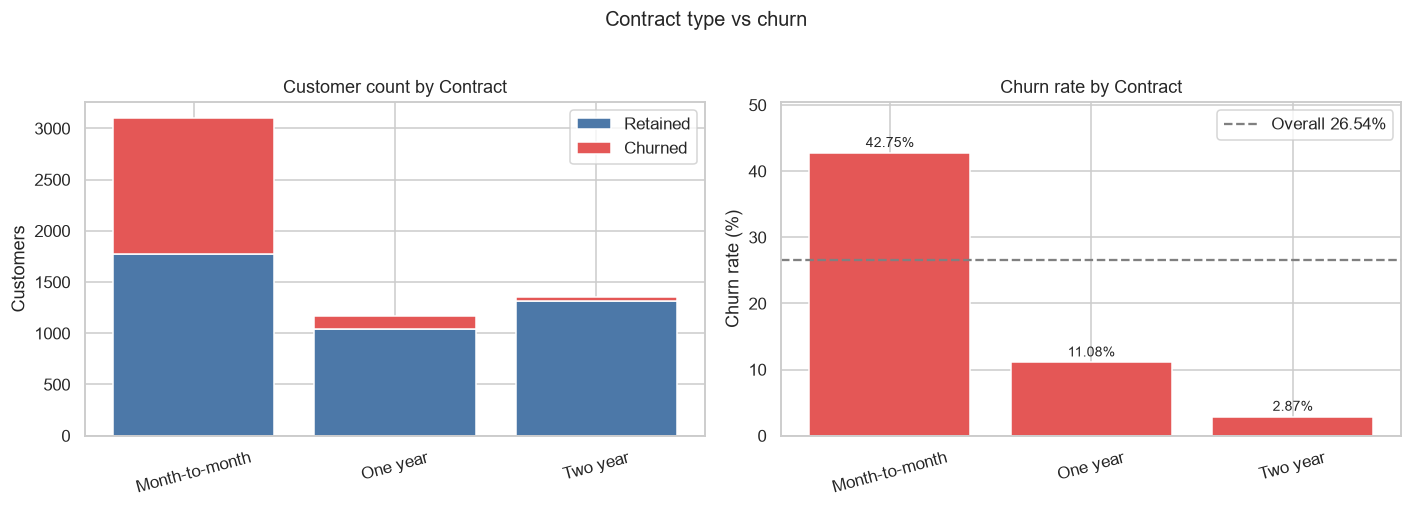

                customers  churned  churn_rate_pct
Contract                                          
Month-to-month       3102     1326           42.75
One year             1173      130           11.08
Two year             1359       39            2.87

Highest: Month-to-month (42.75%)
Lowest : Two year (2.87%)
Ratio  : 14.9x


In [6]:
contract_stats = plot_categorical(
    "Contract", "contract_vs_churn.png", "Contract type vs churn",
    order=["Month-to-month", "One year", "Two year"])
print(contract_stats[["customers", "churned", "churn_rate_pct"]].to_string())

highest = contract_stats["churn_rate"].idxmax()
lowest = contract_stats["churn_rate"].idxmin()
ratio = contract_stats.loc[highest, "churn_rate"] / contract_stats.loc[lowest, "churn_rate"]
print(f"\nHighest: {highest} ({contract_stats.loc[highest, 'churn_rate_pct']:.2f}%)")
print(f"Lowest : {lowest} ({contract_stats.loc[lowest, 'churn_rate_pct']:.2f}%)")
print(f"Ratio  : {ratio:.1f}x")

## 5. Payment method vs churn

saved -> reports/figures/payment_method_vs_churn.png


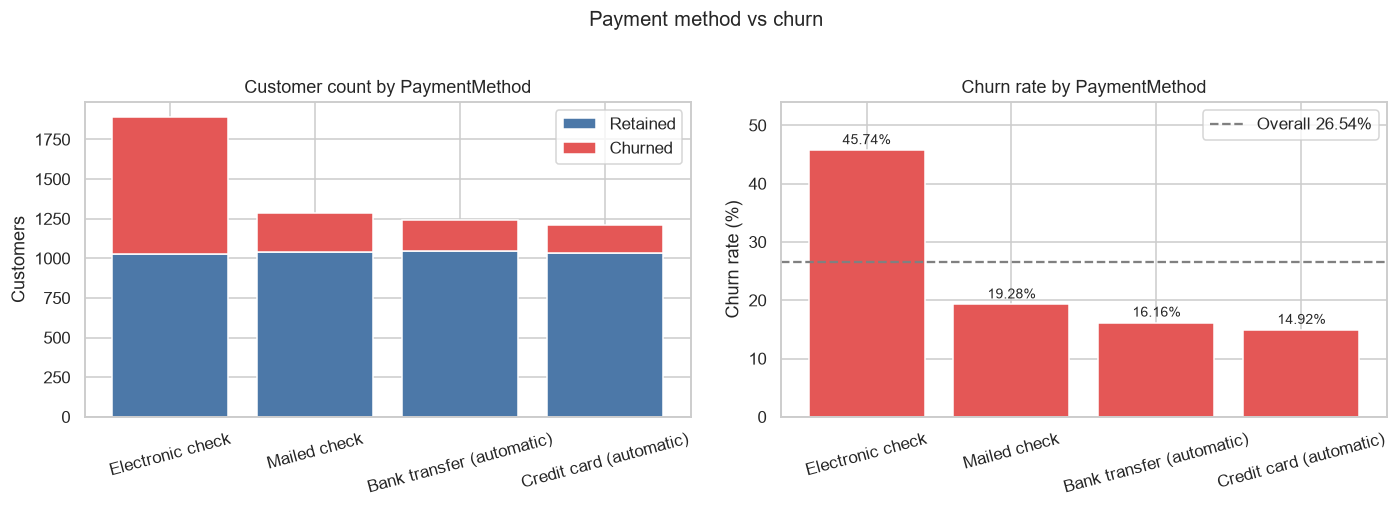

                           customers  churned  churn_rate_pct
PaymentMethod                                                
Electronic check                1891      865           45.74
Mailed check                    1286      248           19.28
Bank transfer (automatic)       1244      201           16.16
Credit card (automatic)         1213      181           14.92

Automatic methods combined: 15.55%
Manual methods combined   : 35.03%


In [7]:
payment_stats = plot_categorical(
    "PaymentMethod", "payment_method_vs_churn.png", "Payment method vs churn")
print(payment_stats[["customers", "churned", "churn_rate_pct"]].to_string())

automatic = ["Bank transfer (automatic)", "Credit card (automatic)"]
manual = ["Electronic check", "Mailed check"]
auto_rate = df[df["PaymentMethod"].isin(automatic)]["Churn"].mean() * 100
manual_rate = df[df["PaymentMethod"].isin(manual)]["Churn"].mean() * 100
print(f"\nAutomatic methods combined: {auto_rate:.2f}%")
print(f"Manual methods combined   : {manual_rate:.2f}%")

## 6. Internet service vs churn

saved -> reports/figures/internet_service_vs_churn.png


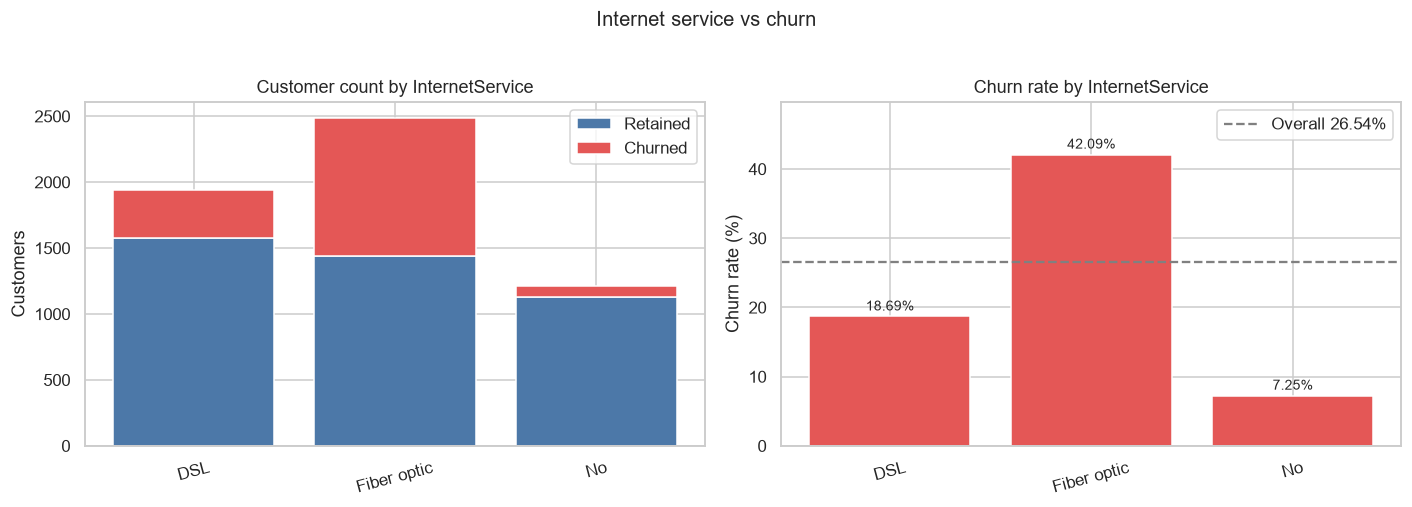

                 customers  churned  churn_rate_pct
InternetService                                    
DSL                   1937      362           18.69
Fiber optic           2483     1045           42.09
No                    1214       88            7.25

Mean monthly charges by internet service:
InternetService
DSL            58.12
Fiber optic    91.67
No             21.11


In [8]:
internet_stats = plot_categorical(
    "InternetService", "internet_service_vs_churn.png",
    "Internet service vs churn", order=["DSL", "Fiber optic", "No"])
print(internet_stats[["customers", "churned", "churn_rate_pct"]].to_string())

print(f"\nMean monthly charges by internet service:")
print(df.groupby("InternetService")["MonthlyCharges"].mean().round(2).to_string())

## 7. Numeric feature relationships

Only genuinely numeric and engineered features are included. One-hot encoded
categoricals are deliberately excluded — correlation between binary indicator
columns is not meaningful and would only inflate the size of the heatmap.

`is_new_customer` is also excluded: it has too few positive cases in the
training split to produce a meaningful correlation (printed below).

is_new_customer positive cases in training split: 8 of 5,634 -- variance too low to be informative, so excluded from the heatmap.



saved -> reports/figures/correlation_heatmap.png


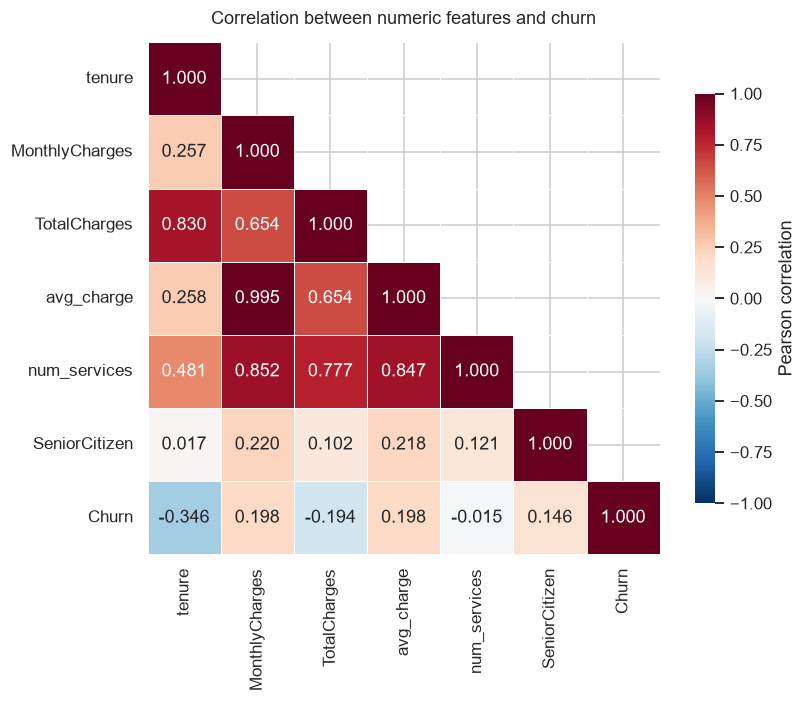

Correlation with churn, strongest first:
  tenure           -0.3456
  MonthlyCharges   +0.1980
  avg_charge       +0.1979
  TotalCharges     -0.1938
  SeniorCitizen    +0.1456
  num_services     -0.0153

Mean value of each numeric feature by churn status:
Churn           retained  churned
tenure             37.59    18.36
MonthlyCharges     61.34    74.86
TotalCharges     2564.72  1564.59
avg_charge         61.27    74.86
num_services        4.19     4.11
SeniorCitizen       0.13     0.25

Strongly correlated feature pairs (|r| > 0.8) -- relevant to Stage 3,
since multicollinearity distorts Logistic Regression coefficients:
  MonthlyCharges <-> avg_charge: 0.9946
  num_services <-> MonthlyCharges: 0.8521
  num_services <-> avg_charge: 0.8469
  tenure <-> TotalCharges: 0.8297


In [9]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges",
                    "avg_charge", "num_services", "SeniorCitizen", "Churn"]

print(f"is_new_customer positive cases in training split: "
      f"{int(df['is_new_customer'].sum())} of {len(df):,} "
      "-- variance too low to be informative, so excluded from the heatmap.\n")

corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation between numeric features and churn", fontsize=12, pad=12)
fig.tight_layout()
save(fig, "correlation_heatmap.png")
plt.show()

print("Correlation with churn, strongest first:")
churn_corr = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
for name, value in churn_corr.items():
    print(f"  {name:<16} {value:+.4f}")

print("\nMean value of each numeric feature by churn status:")
group_means = df.groupby("Churn")[numeric_features[:-1]].mean().round(2)
print(group_means.T.rename(columns={0: "retained", 1: "churned"}).to_string())

print("\nStrongly correlated feature pairs (|r| > 0.8) -- relevant to Stage 3,")
print("since multicollinearity distorts Logistic Regression coefficients:")
pairs = corr.drop(columns="Churn").drop(index="Churn").abs().unstack()
pairs = pairs[pairs < 0.999].sort_values(ascending=False)
seen = set()
for (a, b), value in pairs.items():
    if value <= 0.8 or (b, a) in seen:
        continue
    seen.add((a, b))
    print(f"  {a} <-> {b}: {value:.4f}")

## EDA Findings

Every figure below is computed from the 5,634-row training split. Percentages
are actual churn rates from the data, not estimates.

**1. The classes are imbalanced, so accuracy will be a misleading metric.**
1,495 of 5,634 customers churned (26.54%). Predicting "no churn" for everyone
would score **73.46% accuracy** while identifying zero churners. Recall, F1 and
PR-AUC are the metrics that matter for this problem.

**2. Contract type is the strongest categorical predictor.** Month-to-month
customers churn at **42.75%**, one-year at **11.08%**, and two-year at just
**2.87%** — a **14.9× gap** between the extremes. Contract length alone
separates the population more sharply than any other single field examined.

**3. Churn falls steadily as tenure grows.** The churn rate declines
monotonically across every tenure band: **52.22%** in months 0–6, 37.21% in
7–12, 28.61% in 13–24, and down to **6.81%** in months 61–72. More than half of
customers in their first six months churn. Tenure has the strongest numeric
correlation with churn of any feature (**r = −0.346**).

**4. Higher monthly charges are associated with churn, but not linearly.**
Churned customers pay more on average (**74.86** vs **61.34**). However the
churn rate does *not* rise monotonically with price: it peaks in the third
quartile (70.50–90.00 → **36.98%**) and then *falls* in the most expensive
quartile (90.00–118.75 → **33.29%**). So "higher price means more churn" holds
only up to a point, and the highest-paying customers are not the most at risk.

**5. Electronic check payment stands out sharply.** Churn is **45.74%** for
electronic check, versus 19.28% for mailed check, 16.16% for bank transfer and
**14.92%** for credit card — roughly **3× the credit-card rate**. Grouping by
type, the two automatic methods combine to **15.55%** while the two manual
methods combine to **35.03%**.

**6. Fiber optic customers churn most, despite it being the premium product.**
Fiber optic churns at **42.09%**, DSL at **18.69%**, and customers with no
internet service at only **7.25%**. Fiber optic also carries the highest mean
monthly charge, so price is a plausible contributor — but the size of the gap
suggests service quality or expectations are worth investigating rather than
attributing it to price alone.

**7. Some engineered features are near-duplicates and will need care in
modelling.** `avg_charge` correlates **0.995** with `MonthlyCharges`, and
`num_services` correlates **0.852** with it. This near-collinearity distorts
Logistic Regression coefficients (though tree models are unaffected), which is
worth remembering in Stage 3.

**8. Number of services barely separates the two groups on its own.** Churned
customers average **4.11** services versus **4.19** for retained customers
(**r = −0.015**). Any predictive value it carries is likely to come from
interaction with other features rather than from the count itself.

### Implications for Stage 3

- Use `class_weight="balanced"` (or `scale_pos_weight`) so the 26.54% minority
  class is not ignored, and report recall/F1/PR-AUC alongside accuracy.
- Contract, tenure, payment method and internet service all show strong
  separation and should be informative features.
- The non-monotonic charge relationship favours models that capture
  non-linearity (trees, XGBoost) over purely linear ones.